문제처리 방식

1. 미션 소개 (문제 정의 및 목표 설정)
2. 기본 데이터 입력 및 EDA
3. 전처리 및 증강
4. 드릴 다운 (할 수 있는게 있다면?)
5. 모델링
6. 결과 시각화 (Feature Importance)
7. 결과 생성

In [ ]:
import torch

device = (
    torch.device("cpu") if torch.backends.mps.is_available()
#    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"device : {device}")

device : cpu


# 🚀 0. 미션: SSD 모델을 이용한 개와 고양이 얼굴 감지

이번 미션의 목표는 **SSD(Single Shot MultiBox Detector) 모델**을 사용하여 'The Oxford-IIit Pet Dataset'에 포함된 개와 고양이 이미지에서 얼굴 영역을 찾아내는 Object Detection 모델을 구축하는 것입니다.

### 📋 주요 과제

1.  **데이터 전처리**: 이미지와 XML 형식의 어노테이션(Bounding Box 정보)을 모델 학습에 맞게 가공합니다.
2.  **SSD 모델 구축 및 학습**: 사전 학습된(Pre-trained) SSD 모델을 기반으로 Fine-tuning 하거나, 직접 모델을 구축하여 학습시킵니다.
3.  **모델 예측 및 성능 평가**: 테스트 데이터셋을 사용하여 학습된 모델의 성능을 평가하고, 예측 결과를 시각화합니다.
4.  **결과 제출**: 전체 분석 과정, 코드, 결과 및 설명을 포함한 Colab Notebook 파일을 제출합니다.

-----

### 📂 데이터셋 소개

  * **데이터**: **The Oxford-IIIT Pet Dataset**
      * **images**: 37종의 다양한 개와 고양이 이미지 파일(.jpg)
      * **annotations (xml)**: 각 이미지에 대한 Bounding Box(얼굴 영역 좌표), 클래스(품종) 등의 정보가 담긴 XML 파일

-----

### 📝 제출 파일 가이드

  * **파일명**: `07_{팀명}_{이름}.ipynb` 형식으로 제출합니다.
  * **포함 내용**:
      * **분석 과정과 결과**: 데이터 로드부터 모델 평가까지 모든 과정을 상세히 기록해야 합니다.
      * **마크다운 설명**: 각 코드 셀의 역할과 분석 의도를 명확하게 설명하여, 코드 흐름을 쉽게 이해할 수 있도록 작성해야 합니다. (별도의 보고서가 없으므로 노트북 파일 자체로 완결된 보고서가 되어야 합니다.)
      * **모델 성능 평가**: mAP, IOU 등의 객체 탐지 평가지표를 활용하여 모델 성능을 정량적으로 분석하고, 그 결과를 포함해야 합니다.

-----

### 💻 개발 단계별 상세 가이드

#### 1\. 데이터 준비 (Load & Pre-processing)

  * **데이터 로드**: `images`와 `annotations` 폴더에서 이미지와 XML 파일을 불러옵니다.
  * **XML 파싱**: XML 파일에서 Bounding Box 좌표(`xmin`, `ymin`, `xmax`, `ymax`)와 클래스 라벨 정보를 추출합니다.
  * **데이터셋 생성**: 이미지와 추출한 Bounding Box 정보를 매칭하여 PyTorch 또는 TensorFlow에서 사용할 수 있는 데이터셋 형태로 변환합니다.
  * **데이터 증강 (Data Augmentation)**: 모델의 일반화 성능을 높이기 위해 이미지 자르기, 크기 조절, 색상 변환 등의 기법을 적용하는 것을 권장합니다.

#### 2\. 모델링 (Modeling & Training)

  * **모델 선택**: PyTorch의 `torchvision.models.detection`이나 TensorFlow Hub 등에서 제공하는 사전 학습된 SSD 모델 (예: SSD300)을 불러와 Fine-tuning 하는 방법을 추천합니다.
  * **모델 학습**: 준비된 데이터셋을 사용하여 모델을 학습시킵니다. Optimizer, Scheduler 등을 적절히 설정하여 최적의 성능을 이끌어냅니다.
  * **손실 함수 (Loss Function)**: SSD는 위치 손실(Localization Loss, e.g., Smooth L1)과 분류 손실(Confidence Loss, e.g., Cross-Entropy)을 함께 사용합니다.

#### 3\. 평가 (Evaluation)

  * **성능 지표**:
      * **IOU (Intersection over Union)**: 실제 Bounding Box와 모델이 예측한 Bounding Box가 얼마나 겹치는지를 나타내는 지표입니다.
      * **mAP (mean Average Precision)**: 각 클래스별 AP(Average Precision)의 평균값으로, Object Detection 모델의 전반적인 성능을 평가하는 핵심 지표입니다.
  * **결과 시각화**: 테스트 이미지에 실제 Bounding Box와 모델이 예측한 Bounding Box를 함께 그려 넣어, 모델이 얼마나 정확하게 객체를 탐지하는지 직관적으로 확인합니다.

#### 4\. 제출 (Submission)

  * 위 모든 과정과 결과를 상세한 설명과 함께 Colab Notebook에 정리하여 제출합니다.

-----

### ✨ 참고 및 주의사항

  * **베이스라인 코드**: 제공된 [Baseline 코드](https://www.google.com/search?q=https://www.notion.so/BASELINE-a02931236873489a8523c9a62243d7c3)는 미션 시작을 돕기 위한 참고 자료입니다. 그대로 사용하기보다는, 자신만의 아이디어를 추가하여 모델 성능을 개선해 보세요.
  * **다양한 시도**: 하이퍼파라미터 튜닝, 다른 사전 학습 모델 사용, 데이터 증강 기법 변경 등 다양한 방법으로 성능 향상을 시도해 보는 것이 중요합니다.

이 정리된 내용을 바탕으로 체계적으로 미션을 진행하시면 좋은 결과를 얻으실 수 있을 거예요. 화이팅입니다\! 💪

# 1. 1단계: 기본 데이터 입력 및 EDA

In [ ]:
import os
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt

base_path = ''
image_dir = os.path.join(base_path, 'images/images')
xml_dir = os.path.join(base_path, 'annotations/annotations', 'xmls')


--- XML 파일에서 추출한 정답 정보 ---
이미지 파일명: Abyssinian_1.jpg
정답 Bounding Box 좌표: (xmin:333, ymin:72, xmax:425, ymax:158)


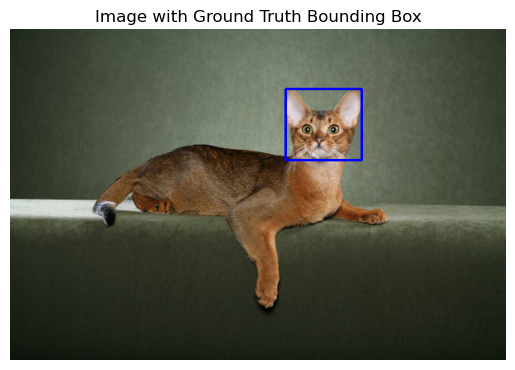

In [ ]:

# 테스트할 이미지 파일명과 XML 파일명을 - byssinian_1.jpg 파일을 예시로 사용.
image_filename = 'Abyssinian_1.jpg'
xml_filename = 'Abyssinian_1.xml'

# XML 파일의 전체 경로
xml_path = os.path.join(xml_dir, xml_filename)

# --- XML 파싱 시작 --- : XML 파일의 내용을 읽고 이해하는 과정
# 1. XML 파일을 엽니다.
tree = ET.parse(xml_path)
root = tree.getroot()

# 2. 'object' 태그 아래의 'bndbox'를 찾습니다.
bndbox = root.find('object/bndbox')

# 3. bndbox 안에서 좌표 값을 찾아 숫자로 변환합니다.
xmin = int(bndbox.find('xmin').text)
ymin = int(bndbox.find('ymin').text)
xmax = int(bndbox.find('xmax').text)
ymax = int(bndbox.find('ymax').text)

print(f"--- XML 파일에서 추출한 정답 정보 ---")
print(f"이미지 파일명: {image_filename}")
print(f"정답 Bounding Box 좌표: (xmin:{xmin}, ymin:{ymin}, xmax:{xmax}, ymax:{ymax})")


# --- 시각화로 확인 ---
image_path = os.path.join(image_dir, image_filename)
image = cv2.imread(image_path)
# OpenCV는 BGR 순서이므로, Matplotlib으로 보려면 RGB로 바꿔줍니다.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 추출한 좌표로 사각형을 그립니다 (파란색, 두께 2)
cv2.rectangle(image_rgb, (xmin, ymin), (xmax, ymax), (0, 0, 255), 2)

# 화면에 보여줍니다.
plt.imshow(image_rgb)
plt.title("Image with Ground Truth Bounding Box")
plt.axis('off')
plt.show()


- 필요할 때마다 하나씩 꺼내 쓸 수 있는 '데이터 관리 시스템'이 필요합. PyTorch에서는 이 역할을 Dataset

In [ ]:
# --- 2. XML 파싱 및 데이터 준비 ---
import xml.etree.ElementTree as ET
from tqdm import tqdm

# parse_xml 함수는 이전과 동일합니다.
def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    objects = []
    for obj in root.findall('object'):
        name = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)
        objects.append({'name': name, 'bndbox': [xmin, ymin, xmax, ymax]})
    return objects


In [ ]:
import glob # 파일 경로를 쉽게 검색하기 위한 라이브러리

# ====모든 이미지 파일의 경로를 리스트로 가져옴 === (glob.glob은 특정 패턴과 일치하는 모든 파일 경로를 찾아 리스트로 반환)
# 'image_dir/*.jpg'는 image_dir 폴더 안에 있는 모든 .jpg 파일을 의미합니다.
image_paths = glob.glob(os.path.join(image_dir, '*.jpg'))

print(f"발견된 총 이미지 파일 수: {len(image_paths)}")

발견된 총 이미지 파일 수: 7390


In [ ]:
import pandas as pd

# ==== 이미지와 그에 해당하는 XML 파일이 모두 존재하는 데이터만 골라내기 ==== (이미지 파일은 있지만 어노테이션 파일이 없는 경우, 학습에 사용할 수 없으므로 제외).
data = []
for img_path in tqdm(image_paths, desc="파일 쌍 확인 중"):
    # 이미지 파일 이름(확장자 제외)을 추출. (예: 'images/images/Abyssinian_1.jpg' -> 'Abyssinian_1')
    img_name = os.path.splitext(os.path.basename(img_path))[0]
    # 해당 이미지 이름과 동일한 XML 파일의 경로를 구성합니다.
    xml_path = os.path.join(xml_dir, img_name + '.xml')

    # 만약 해당 XML 파일이 실제로 존재한다면,
    if os.path.exists(xml_path):
        # (이미지 경로, XML 경로) 쌍을 데이터 리스트에 추가합니다.
        data.append((img_path, xml_path))

print(f"이미지-XML 쌍이 일치하는 데이터 수: {len(data)}")

# 필요성: 이렇게 찾아낸 파일 목록을 다루기 쉬운 DataFrame 형태로 변환합니다.
# 이제 이 DataFrame이 데이터셋의 기초가 되며, 'trainval.txt' 파일은 더 이상 필요 없습니다.
df = pd.DataFrame(data, columns=['image_path', 'xml_path'])
df.head()

파일 쌍 확인 중: 100%|██████████████████| 7390/7390 [00:00<00:00, 128116.14it/s]

이미지-XML 쌍이 일치하는 데이터 수: 3686


,image_path,xml_path
0,images/images/basset_hound_112.jpg,annotations/annotations/xmls/basset_hound_112.xml
1,images/images/Siamese_193.jpg,annotations/annotations/xmls/Siamese_193.xml
2,images/images/shiba_inu_122.jpg,annotations/annotations/xmls/shiba_inu_122.xml
3,images/images/Birman_167.jpg,annotations/annotations/xmls/Birman_167.xml
4,images/images/shiba_inu_136.jpg,annotations/annotations/xmls/shiba_inu_136.xml


In [ ]:
# DataFrame에 'annotations' 컬럼을 추가합니다.
df['annotations'] = df['xml_path'].apply(parse_xml)

# --- [수정된 부분] ---
# 필요성: 올바른 데이터 구조에 접근하여 클래스 레이블을 생성합니다.
def get_species_label(annotation_list):
    # annotation_list는 [{...}] 형태의 리스트이므로, 첫 번째 요소([0])를 선택해야 합니다.
    # 만약 리스트가 비어있다면 None을 반환하여 오류를 방지합니다.
    if not annotation_list:
        return None
    # 리스트의 첫 번째 딕셔너리에서 'name' 키를 이용해 클래스 이름을 가져옵니다.
    class_name = annotation_list[0]['name']

    # 클래스 이름의 첫 글자가 대문자('A'-'Z')이면 2(개), 아니면 1(고양이)을 반환합니다.
    if 'A' <= class_name[0] <= 'Z':
        return 2 # Dog
    else:
        return 1 # Cat
# --------------------

# 수정된 함수를 'annotations' 컬럼에 적용하여 'species'라는 새 컬럼을 만듭니다.
df['species'] = df['annotations'].apply(get_species_label)

# 혹시 레이블을 생성하지 못한 데이터가 있다면 제거합니다.
df.dropna(subset=['species'], inplace=True)
# species 레이블을 정수형으로 변환합니다.
df['species'] = df['species'].astype(int)


# 최종적으로 생성된 데이터프레임을 확인합니다.
print("최종 데이터프레임 정보:")
df.info()
df.head()

최종 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3686 entries, 0 to 3685
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image_path   3686 non-null   object
 1   xml_path     3686 non-null   object
 2   annotations  3686 non-null   object
 3   species      3686 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 115.3+ KB


,image_path,xml_path,annotations,species
0,images/images/basset_hound_112.jpg,annotations/annotations/xmls/basset_hound_112.xml,"[{'name': 'dog', 'bndbox': [129, 146, 314, 321]}]",1
1,images/images/Siamese_193.jpg,annotations/annotations/xmls/Siamese_193.xml,"[{'name': 'cat', 'bndbox': [125, 68, 282, 236]}]",1
2,images/images/shiba_inu_122.jpg,annotations/annotations/xmls/shiba_inu_122.xml,"[{'name': 'dog', 'bndbox': [30, 81, 250, 343]}]",1
3,images/images/Birman_167.jpg,annotations/annotations/xmls/Birman_167.xml,"[{'name': 'cat', 'bndbox': [192, 63, 314, 176]}]",1
4,images/images/shiba_inu_136.jpg,annotations/annotations/xmls/shiba_inu_136.xml,"[{'name': 'dog', 'bndbox': [139, 106, 228, 216]}]",1


- 데이터를 텐서로 변환하기
 - 이미지 데이터의 차원 순서도 PyTorch 표준인 [채널, 높이, 너비] 순으로 자동으로 변경

In [ ]:
# --- 3. PyTorch 커스텀 데이터셋 생성 ---
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

# 클래스 ID와 실제 이름 매핑 (시각화 시 사용)
classes = {1: 'cat', 2: 'dog'}

class PetDataset(Dataset):
    # 객체 생성 시 DataFrame과 변환(transform) 규칙을 입력받습니다.
    def __init__(self, df, transforms=None):
        self.df = df
        self.transforms = transforms

    # 데이터셋의 전체 길이를 반환합니다.
    def __len__(self):
        return len(self.df)

    # 특정 인덱스(idx)의 데이터를 요청받았을 때 실행됩니다.
    def __getitem__(self, idx):
        # 주어진 인덱스에 해당하는 행(row)의 정보를 가져옵니다.
        row = self.df.iloc[idx]
        image_path = row['image_path']

        # PIL을 사용해 이미지를 엽니다.
        image = Image.open(image_path).convert("RGB")
        label = row['species']

        # --- [수정된 부분] ---
        # row['annotations']는 리스트이므로, 첫 번째 요소([0])를 먼저 꺼내야 합니다.
        annotation_dict = row['annotations'][0]
        box = annotation_dict['bndbox']
        # ---------------------

        # 모델이 요구하는 'target' 형식(딕셔셔리)을 만듭니다.
        target = {}
        target["boxes"] = torch.as_tensor([box], dtype=torch.float32) # 박스는 리스트 안에 담아 전달
        target["labels"] = torch.as_tensor([label], dtype=torch.int64) # 레이블도 리스트 안에 담아 전달

        # 이미지에 전처리(transforms)를 적용합니다.
        if self.transforms:
            image = self.transforms(image)

        return image, target



# 이미지 -> 텐서 변환
transforms = T.Compose([T.ToTensor()])

# 데이터셋 객체 생성
# 이제 train/validation을 나눠야 합니다. 여기서는 간단히 전체 데이터를 사용합니다.
# 추후 scikit-learn의 train_test_split을 사용해 df를 나눌 수 있습니다.
full_dataset = PetDataset(df, transforms=transforms)

def collate_fn(batch):
    return tuple(zip(*batch))

## 2) 데이터 분할

In [ ]:
# --- 3.5 데이터 분할 ---
from sklearn.model_selection import train_test_split

# 필요성: 전체 데이터프레임(df)을 학습용(df_train)과 테스트용(df_test)으로 나눕니다.
# test_size=0.2: 전체 데이터의 20%를 테스트용으로 사용합니다.
# random_state=42: 항상 동일한 방식으로 데이터가 나뉘도록 하여 실험 결과를 재현할 수 있게 합니다.
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['species'])

print(f"총 데이터: {len(df)}")
print(f"학습 데이터: {len(df_train)}")
print(f"validation 데이터: {len(df_val)}")

총 데이터: 3686
학습 데이터: 2948
validation 데이터: 738


In [ ]:
train_dataset = PetDataset(df_train, transforms=transforms)
val_dataset = PetDataset(df_val, transforms=transforms)

# 학습용/테스트용 데이터로더는 데이터를 섞어서(shuffle=True) 모델이 순서에 과적합되는 것을 방지합니다.
#train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
#test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

train_loader = DataLoader(
    train_dataset,
    batch_size=4, # 이전에 2로 줄였습니다.
    shuffle=True,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
)

## 4) 모델 설계

- 'Faster R-CNN'이라는 유명한 모델을, 마지막 출력 부분만 우리에게 맞게 (배경, 고양이, 개) 살짝 바꿔주자
- 따라서 num=3 이 되어야함

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 우리의 목적(클래스 3개)에 맞게 사전 학습된 모델을 개조하는 함수입니다.
def get_model(num_classes):
    # torchvision에 이미 만들어져 있는 'Faster R-CNN' 모델을 불러옵니다.
    # weights='DEFAULT'는 가장 최신 버전의 사전 학습된 가중치를 사용하겠다는 의미입니다.
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

    # 모델의 최종 예측 부분(분류기)의 입력 뉴런 수를 알아냅니다.
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # 알아낸 입력 뉴런 수를 유지하면서, 출력 뉴런 수만 우리의 클래스 수에 맞게 교체합니다.
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

- 옵티마이저와 GPU 설정

In [ ]:
import torch

# 클래스 수 (배경, 고양이, 개)
num_classes = 3

# 위에서 정의한 get_model 함수를 호출하여 실제 모델을 생성합니다.
model = get_model(num_classes)
model.to(device) # 생성된 모델을 설정된 장치(GPU 또는 CPU)로 보냅니다.

# Optimizer:
# SGD Optimizer를 사용하고, 학습률(lr) 등 주요 파라미터를 설정합니다. (일반적으로 Faster에는 ADAM보다 SGD가 더 좋다고 알려짐)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
print(f"모델이 준비되었습니다. 현재 사용 중인 장치: {device}")

모델이 준비되었습니다. 현재 사용 중인 장치: cpu


- 모델 함수 만들기


In [ ]:
from tqdm.auto import tqdm # auto는 Colab/Jupyter 환경에 더 최적화된 tqdm입니다.

def train_detection_model(model, train_loader, optimizer, num_epochs):
    """객체 탐지 모델을 학습시키는 함수"""

    # 각 에포크의 손실을 기록할 리스트
    history = {'train_loss': []}

    for epoch in range(num_epochs):
        model.train() # 모델을 학습 모드로 설정
        epoch_loss = 0

        # 데이터로더에서 배치 단위로 데이터를 가져와 학습
        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            # 데이터(이미지, 정답)를 GPU로 보냄
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # 1. 모델이 예측하고, 정답과 비교하여 '오차(loss)' 계산
            # 객체 탐지 모델은 loss_dict 형태로 다양한 손실 값들을 반환합니다.
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            # 2. 오차를 줄이는 방향으로 모델의 파라미터를 업데이트(학습)
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            # 현재 배치의 손실을 더함
            epoch_loss += losses.item()

        # 한 에포크의 평균 손실을 계산하고 기록
        avg_epoch_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_epoch_loss)
        print(f"✅ Epoch {epoch+1} Loss: {avg_epoch_loss:.4f}")

    print("🎉 학습 완료!")
    return model, history

In [ ]:
import os

# MPS Fallback 기능을 비활성화하여 잠재적 충돌을 방지합니다.
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '0'

In [ ]:
num_epochs = 1
trained_model, history = train_detection_model(model, train_loader, optimizer, num_epochs)

# 학습 과정의 손실(loss) 변화를 확인할 수 있습니다.
print("\n학습 손실 기록:")
print(history['train_loss'])

Epoch 1/1:   0%|          | 0/737 [00:00<?, ?it/s]

KeyboardInterrupt: 

- 이걸 쓰기엔 너무 힘듦.
    - 속도가 많이 늦음. 212/737, 8.79s/it -> 28:31,
    - Batch 사이즈를 4이상 올리기가 힘듦. (Batch size를 8,4,2로 변경해봄)
    - 한번에 처리 양이 너무 많아서 mpu에 올리기도 힘듦.
    - 강제종료하기로 함.

🧐 R-CNN의 작동 방식:
 - 1단계 (RPN): 입력 이미지로부터 객체가 존재할 확률이 높은 후보 영역(Region of Interest)을 다수 추출함.
 - 2단계: 추출된 각 후보 영역에 대해 클래스를 판별하고, 경계 상자(Bounding Box)의 위치를 정밀하게 조정하는 회귀(Regression) 작업을 수행함.
    - 성능 특성: 다단계 검증을 통해 높은 정확도를 달성하나, 복잡한 파이프라인으로 인해 추론 속도가 상대적으로 느림.
  
⚡ YOLO & SSD: "한 번에 풀기" (직관적 접근)
 - 이 모델들은 객체 탐지를 하나의 문제로 보고 한 번에 해결합니다.
 - "어디에 무엇이 있는지?" 를 사진을 한 번만 보고 동시에 알아냅니다.
 - 비유: 방 입구에서 전체를 쓱 훑어보자마자 "아, 열쇠 테이블 위에 있네!"라고 바로 알아채는 것과 같습니다. 순간적이고 매우 빠릅니다.

- SSD와 YOLO는 둘 다 1단계 탐지기라 빠름.
- 다만, YOLO는 이미지를 통째로 한 번에 처리하는 방식이 극단적으로 단순하고 효율적이기 때문에, 초당 처리할 수 있는 프레임 수(FPS)에서 거의 항상 우위를 보임.
- "정확도가 가장 중요한가 SSD, 아니면 실시간 속도가 가장 중요한가? YOLO"

## 2)  SSD 로 코딩을 시작해보자

In [ ]:
import torch

device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"device : {device}")

device : mps


In [ ]:
from tqdm.auto import tqdm # auto는 Colab/Jupyter 환경에 더 최적화된 tqdm입니다.

def train_detection_model(model, train_loader, optimizer, num_epochs):
    """객체 탐지 모델을 학습시키는 함수"""

    # 각 에포크의 손실을 기록할 리스트
    history = {'train_loss': []}

    for epoch in range(num_epochs):
        model.train() # 모델을 학습 모드로 설정
        epoch_loss = 0

        # 데이터로더에서 배치 단위로 데이터를 가져와 학습
        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            # 데이터(이미지, 정답)를 GPU로 보냄
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # 1. 모델이 예측하고, 정답과 비교하여 '오차(loss)' 계산
            # 객체 탐지 모델은 loss_dict 형태로 다양한 손실 값들을 반환합니다.
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            # 2. 오차를 줄이는 방향으로 모델의 파라미터를 업데이트(학습)
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            # 현재 배치의 손실을 더함
            epoch_loss += losses.item()

        # 한 에포크의 평균 손실을 계산하고 기록
        avg_epoch_loss = epoch_loss / len(train_loader)
        history['train_loss'].append(avg_epoch_loss)
        print(f"✅ Epoch {epoch+1} Loss: {avg_epoch_loss:.4f}")

    print("🎉 학습 완료!")
    return model, history

In [ ]:
import torchvision
from torchvision.models.detection.ssd import SSDClassificationHead

def get_model(num_classes):
    # 1. torchvision에서 사전 학습된 SSD300 모델을 불러옵니다.
    model = torchvision.models.detection.ssd300_vgg16(weights='DEFAULT')

    # 2. 모델의 최종 예측 부분(분류기 헤드)에 필요한 정보를 직접 지정합니다.
    in_channels = [512, 1024, 512, 256, 256, 256]

    # --- [수정된 부분] ---
    # 이전 코드에서는 이 값을 읽어오려고 했지만, 여기서는 미리 약속된 고정값을 사용합니다.
    num_anchors = [4, 6, 6, 6, 4, 4] # SSD300_VGG16의 고정된 앵커 수
    # --------------------

    # 3. 출력 뉴런 수만 우리의 클래스 수(배경, 고양이, 개)에 맞게 새로운 헤드를 만듭니다.
    model.head.classification_head = SSDClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes
    )
    return model

In [ ]:
pip install torchmetrics[detection]

zsh:1: no matches found: torchmetrics[detection]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from torchmetrics.detection import MeanAveragePrecision
from pprint import pprint # 딕셔너리를 예쁘게 출력하기 위해 사용

def evaluate_model(model, data_loader, device):
    """학습된 모델의 mAP 성능을 평가합니다."""

    # 1. mAP 계산기 객체를 생성합니다.
    metric = MeanAveragePrecision()

    # 2. 모델을 평가 모드로 설정합니다.
    model.eval()

    with torch.no_grad(): # 그래디언트 계산을 비활성화하여 메모리 사용량 줄이고 속도 높임
        # 3. 테스트 데이터로더에서 데이터를 하나씩 가져옵니다.
        for images, targets in tqdm(data_loader, desc="평가 진행 중"):
            images = [img.to(device) for img in images]

            # 4. 모델을 통해 예측을 수행합니다.
            predictions = model(images)

            # 5. 예측 결과와 실제 정답을 mAP 계산기에 업데이트합니다.
            #    계산기는 CPU에서 작동하므로, 데이터를 CPU로 옮겨줍니다.
            preds_cpu = [{k: v.to('cpu') for k, v in p.items()} for p in predictions]
            targets_cpu = [{k: v.to('cpu') for k, v in t.items()} for t in targets]
            metric.update(preds_cpu, targets_cpu)

    # 6. 모든 데이터에 대한 평가가 끝나면, 최종 mAP 점수를 계산합니다.
    mAP_dict = metric.compute()
    return mAP_dict




In [ ]:
transforms = T.Compose([
    T.Resize((300, 300)),
    T.ToTensor()
])

In [ ]:
from tqdm.auto import tqdm

# 이전에 만든 mAP 평가 함수 'evaluate_model'이 이 함수 안에서 사용됩니다.
# evaluate_model 함수가 이 코드보다 먼저 정의되어 있어야 합니다.

def train_model_with_validation(model, train_loader, val_loader, optimizer, num_epochs):
    # epoch별 손실과 mAP를 기록할 딕셔너리
    history = {'train_loss': [], 'val_map': []}

    for epoch in range(num_epochs):
        # --- 훈련 단계 ---
        model.train()
        running_loss = 0.0

        for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train"):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # 손실 계산 (기존 객체 탐지 방식과 동일)
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            # 파라미터 업데이트
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            running_loss += losses.item()

        # 평균 훈련 손실 계산
        epoch_loss = running_loss / len(train_loader)
        history['train_loss'].append(epoch_loss)

        # --- 검증 단계 ---
        # 이전에 우리가 만든 mAP 평가 함수를 여기서 호출합니다.
        # 이 함수는 model.eval()과 torch.no_grad()를 내부적으로 처리해줍니다.
        val_map_dict = evaluate_model(model, val_loader, device)
        val_map = val_map_dict['map'] # 전체 mAP 점수를 가져옵니다.
        history['val_map'].append(val_map.item())
        trained_model = model
        # 결과 출력
        print(f"Train Loss: {epoch_loss:.4f} | Val mAP: {val_map:.4f}")

    print("🎉 최종 학습 완료!")
    return trained_model, history

In [ ]:
import torch

# --- 1. 모델 생성 ---
# 클래스 수 (배경, 고양이, 개)
num_classes = 3

# 우리가 SSD용으로 수정한 get_model 함수를 호출하여 실제 모델을 생성합니다.
model = get_model(num_classes)
model.to(device) # 모델을 GPU(mps) 또는 CPU로 보냅니다.

# --- 2. 옵티마이저 및 스케줄러 설정 ---
# 모델의 파라미터를 학습시킬 최적화 도구를 설정합니다. 기존 SGD 설정을 그대로 사용합니다.
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)
# 학습률을 주기적으로 조절할 스케줄러를 설정합니다.
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print(f"✅ SSD 모델 생성 완료. 학습을 시작합니다. (Device: {device})")


# --- 3. 학습 실행 ---
# 전체 데이터셋을 총 몇 번 반복 학습할지 결정합니다. (테스트로 10번으로 설정)
num_epochs = 30

# 이전에 만들어 둔 학습 함수를 실행시켜 실제 훈련에 돌입합니다.
trained_model, history = train_model_with_validation(model, train_loader, test_loader, optimizer, num_epochs)

# --- 4. 결과 확인 ---
# 학습 과정의 손실(loss) 변화를 출력하여 학습이 잘 되었는지 확인합니다.
print("\\n학습 손실 기록:")
print(history['train_loss'])

# --- 실제 평가 실행 ---
# 이전에 학습시킨 trained_model과 test_loader를 사용합니다.
mAP_results = evaluate_model(model, test_loader, device)

print("\\n--- 최종 성능 평가 결과 (mAP) ---")
pprint(mAP_results)

✅ SSD 모델 생성 완료. 학습을 시작합니다. (Device: mps)


Epoch 1/30 - Train:   0%|          | 0/737 [00:00<?, ?it/s]

평가 진행 중:   0%|          | 0/185 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Train Loss: 2.5784 | Val mAP: 0.5899


...

Epoch 30/30 - Train:   0%|          | 0/737 [00:00<?, ?it/s]

평가 진행 중:   0%|          | 0/185 [00:00<?, ?it/s]

Train Loss: 0.0412 | Val mAP: 0.7692
🎉 최종 학습 완료!
\n학습 손실 기록:
[2.5784397647694624, 1.5831846192863288, 1.2511006533048208, 0.9715280590257942, 0.8566278714580484, 0.6774325581871509, 0.5035876175805704, 0.41599698635664856, 0.35727183688608893, 0.30157505959434133, 0.2652340501931015, 0.23524951032050753, 0.2236564678002245, 0.18785899004101592, 0.1648902510023667, 0.14646270851449208, 0.1229417763518996, 0.10793373299562947, 0.09855080505623261, 0.09352610348704873, 0.08576946073746261, 0.07443129436303754, 0.07138585509022184, 0.06316669220850377, 0.05831287940774553, 0.054424819092960014, 0.04954385437991273, 0.04849468371761379, 0.04534250656534568, 0.041245459014072186]


평가 진행 중:   0%|          | 0/185 [00:00<?, ?it/s]

\n--- 최종 성능 평가 결과 (mAP) ---
{'classes': tensor(1, dtype=torch.int32),
 'map': tensor(0.7692),
 'map_50': tensor(0.9787),
 'map_75': tensor(0.9211),
 'map_large': tensor(0.7858),
 'map_medium': tensor(0.6995),
 'map_per_class': tensor(-1.),
 'map_small': tensor(-1.),
 'mar_1': tensor(0.8199),
 'mar_10': tensor(0.8215),
 'mar_100': tensor(0.8215),
 'mar_100_per_class': tensor(-1.),
 'mar_large': tensor(0.8368),
 'mar_medium': tensor(0.7496),
 'mar_small': tensor(-1.)}


- Epoch 당 1분정도 걸림. (mps 도 사용가능)

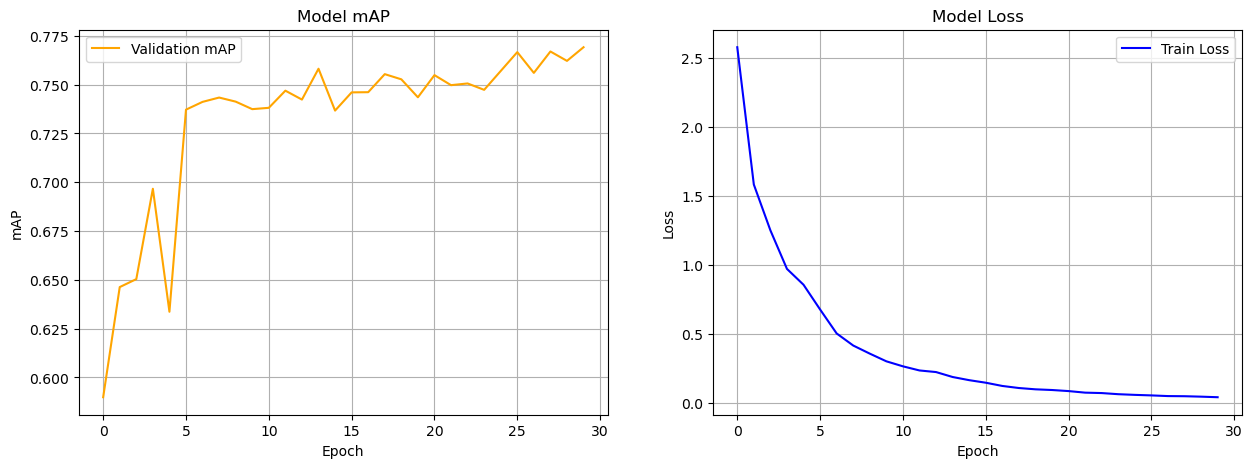

In [ ]:
import matplotlib.pyplot as plt

def plot_detection_history(history):
    """객체 탐지 모델의 학습 과정(손실과 mAP)을 그래프로 그립니다."""

    # 그래프를 2개 그리기 위한 설정 (mAP용, Loss용)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- 1. mAP(mean Average Precision) 그래프 ---
    # history 딕셔너리에서 'val_map' 값을 가져와 그립니다.
    ax1.plot(history['val_map'], label='Validation mAP', color='orange')
    ax1.set_title('Model mAP')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('mAP')
    ax1.legend()
    ax1.grid(True)

    # --- 2. 손실(Loss) 그래프 ---
    # history 딕셔너리에서 'train_loss' 값을 가져와 그립니다.
    ax2.plot(history['train_loss'], label='Train Loss', color='blue')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.show()

# --- 실제 함수 실행 ---
# 이전에 모델을 학습시키고 얻은 history 객체를 넣어줍니다.
plot_detection_history(history)

In [ ]:
import numpy as np

def box_iou(boxA, boxB):
    """
    boxA, boxB: [xmin, ymin, xmax, ymax] (숫자 또는 numpy array)
    returns IoU (float)
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interW = max(0.0, xB - xA)
    interH = max(0.0, yB - yA)
    interArea = interW * interH

    boxAArea = max(0.0, boxA[2] - boxA[0]) * max(0.0, boxA[3] - boxA[1])
    boxBArea = max(0.0, boxB[2] - boxB[0]) * max(0.0, boxB[3] - boxB[1])

    unionArea = boxAArea + boxBArea - interArea
    if unionArea == 0:
        return 0.0
    return interArea / unionArea

In [ ]:
print(mAP_results)

{'map': tensor(0.7692), 'map_50': tensor(0.9787), 'map_75': tensor(0.9211), 'map_small': tensor(-1.), 'map_medium': tensor(0.6995), 'map_large': tensor(0.7858), 'mar_1': tensor(0.8199), 'mar_10': tensor(0.8215), 'mar_100': tensor(0.8215), 'mar_small': tensor(-1.), 'mar_medium': tensor(0.7496), 'mar_large': tensor(0.8368), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}


| 지표       | IoU 기준 (%) | 값      | 해석 (위치 정밀도)                                  |
| -------- | ---------- | ------ | -------------------------------------------- |
| mAP@50   | 50         | 0.9787 | 탐지 능력은 최상위. 객체 발견 및 분류는 완벽에 가까움.             |
| mAP@75   | 75         | 0.9211 | IoU 75% 기준에서도 90% 이상 성능 기록. 경계 박스의 위치 정밀도 우수성 확인.                    |
| mAP (종합) | 50∼95 평균   | 0.7692 | 뛰어난 종합 성능. 다만, mAP@50과의 격차가 정밀도 향상 필요성을 시사함. |


A. 위치 정밀도(IoU) 격차 심층 분석
 - 격차 발생: 최고 성능 지표인 mAP@50 (0.9787) 대비 종합 성능 지표인 mAP (0.7692)에서 약 $21%$p의 격차 발생 확인.
 - 격차의 의미:
    - 주로 IoU 80% 이상의 극히 높은 정밀도 요구 구간에서 성능 하락 발생 시사.
    - 객체의 존재 파악은 완벽하나, 미세 경계(Fine-grained Boundary) 예측 정확도 취약점 확인.
    - 오차 허용 범위가 좁은 첨단 기계 설계 및 소재 분석 분야 적용을 위한 최우선 개선 과제임.

- 개인적인 코멘트 : 아직까지 mAP 의 의미 및 어느정도가 정량적으로 높은 수치인지 감이 안생김.
    - 여러번에 코딩으로 감을 익혀나갈 예정

# 멘토코멘트

Object Detection에 대한 깊은 이해를 바탕으로 우수한 연구를 진행했습니다. 특히 미션 가이드 작성이 매우 상세하며, SSD 모델의 핵심 개념과 손실 함수를 명확하게 설명한 점이 돋보입니다. 7단계 문제 처리 방식(미션 소개, 기본 데이터 입력 및 EDA, 전처리 및 증강, 드릴 다운, 모델링, 결과 시각화, 결과 생성)을 제시하여 전체 프로젝트의 흐름을 논리적으로 구성했습니다.


주요 강점으로는 체계적인 7단계 문제 처리 방식, 매우 상세한 미션 가이드 작성, SSD 손실 함수에 대한 명확한 설명을 들 수 있습니다. 위치 손실(Localization Loss, Smooth L1)과 분류 손실(Confidence Loss, Cross-Entropy)의 개념을 정확히 이해하고 설명했으며, IOU(Intersection over Union)와 mAP(mean Average Precision)라는 Object Detection의 핵심 평가 지표를 상세히 설명했습니다. XML 파싱을 통한 Bounding Box 정보 추출과 Ground Truth Bounding Box를 시각화한 점, PyTorch Dataset 개념을 "데이터 관리 시스템"으로 명확히 설명한 점이 우수합니다. The Oxford-IIIT Pet Dataset을 활용한 명확한 주제 설정, 디바이스 최적화(CPU 우선 설정) 고려, Fine-tuning 전략의 논리적 설계, torchvision.models.detection 활용 계획도 적절합니다.


향후 발전을 위해서는 몇 가지 보완이 필요합니다. 실제 모델 훈련 결과를 구체적으로 제시하고, 하이퍼파라미터 튜닝과 다양한 사전 학습 모델 사용, 데이터 증강 기법 변경을 통한 성능 개선 실험과 그 결과를 명확히 문서화해야 합니다. 코드를 함수화하고 모듈화하여 재사용성과 유지보수성을 높이고, 코드 블록에 대한 주석을 보강하여 가독성을 개선해야 합니다. 예측 결과 시각화를 추가하여 모델의 실제 성능을 직관적으로 보여주고, 실제 Bounding Box와 예측 Bounding Box를 비교하는 시각화를 구현한다면 연구의 완성도를 크게 높일 수 있습니다. 전반적으로 Object Detection의 이론적 이해와 실무적 적용 능력이 모두 우수한 프로젝트이며, 실험 결과 문서화와 코드 품질 측면을 보완한다면 더욱 완성도 높은 결과물이 나올 것입니다.